# Dados

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import numpy as np

In [2]:
data = fetch_california_housing()
X, y = data.data, data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
# normalização dos dados (0-1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Métricas
y_pred = modelo.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)


MSE: 0.5305677824766752
R2: 0.5957702326061665


O R2 saiu bem baixo.

## Bagging

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# Bagging
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
bagging.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=42)

In [ ]:
# Métricas
y_pred_bag = bagging.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)
print("MSE:", mse_bag)
print("R2:", r2_bag)


MSE: 0.2868006463848945
R2: 0.7814918990455971


O R2 aumentou então melhorou nosso modelo.

## Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# Boosting
boosting = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
boosting.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# Métricas
y_pred_boost = boosting.predict(X_test)
mse_boost = mean_squared_error(y_test, y_pred_boost)
r2_boost = r2_score(y_test, y_pred_boost)
print("MSE:", mse_boost)
print("R2:", r2_boost)


MSE: 0.2883049771484818
R2: 0.7803457772969118


O R2 ficou bem parecido com o bagging então não valeu tanto a pena.

# Stacking

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR

In [ ]:
# Stacking
estimators = [
    ('dt', RidgeCV()),
    ('svr', SVR())
]
stacking = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking.fit(X_train, y_train)

StackingRegressor(estimators=[('dt', RidgeCV()), ('svr', SVR())],
                  final_estimator=LinearRegression())

In [ ]:
# Métricas
y_pred_stack = stacking.predict(X_test)
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)
print("MSE:", mse_stack)
print("R2:", r2_stack)

MSE: 0.3371159411546158
R2: 0.7431576077959946


R2 menor que bagging e boosting. Não compensou e demorou pra rodar

# Comparativo

In [ ]:
import matplotlib.pyplot as plt

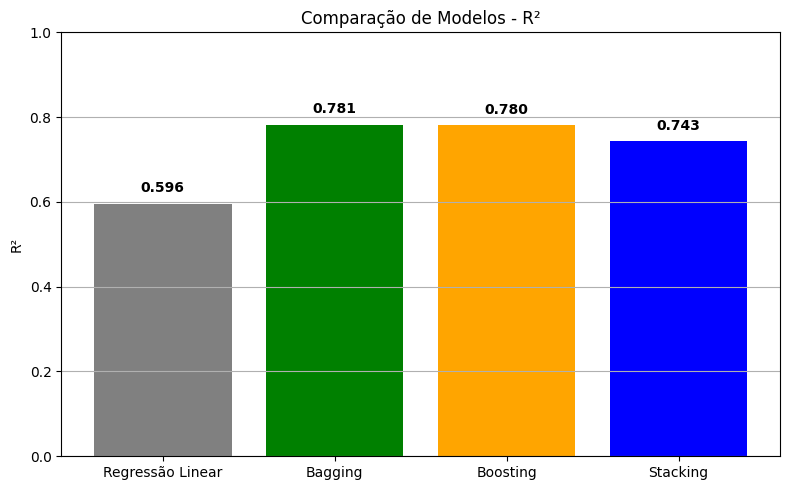

In [ ]:
# Visualização

scores = [
    r2_score(y_test, y_pred),         # Regressão Linear
    r2_score(y_test, y_pred_bag),     # Bagging
    r2_score(y_test, y_pred_boost),   # Boosting
    r2_score(y_test, y_pred_stack)    # Stacking
]

labels = ['Regressão Linear', 'Bagging', 'Boosting', 'Stacking']


plt.figure(figsize=(8,5))
bars = plt.bar(labels, scores, color=['gray', 'green', 'orange', 'blue'])
plt.ylabel("R²")
plt.title("Comparação de Modelos - R²")
plt.ylim(0, 1)
plt.grid(True, axis='y')

for bar, score in zip(bars, scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{score:.3f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()